In [8]:
# importing libraries
import math
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from graphviz import Digraph

In [14]:
class Engine:
    def __init__(self,data,children = (),_op='',label=''):
        self.data = data
        self.prev = set(children)
        self.label = label
        self._op = _op
    def __repr__(self):
        return f"(value={self.data})"
    def __add__(self, other):
        return Engine(self.data + other.data,(self,other),'+' )
    def __mul__(self, other):
        return Engine(self.data*other.data, (self,other),'*')

In [15]:
x1 = Engine(2.0); x1.label = 'x1'
x2 = Engine(3.0); x2.label = 'x2'
w1 = Engine(1.0); w1.label = 'w1'
w2 = Engine(0.0); w2.label = 'w2'
b = Engine(6.887877787); b.label = 'b'

In [16]:
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
val = x1w1 + x2w2 + b; val.label = 'out'
print(x1w1.prev)
print(x2w2.prev)
print(val.prev)

{(value=1.0), (value=2.0)}
{(value=0.0), (value=3.0)}
{(value=6.887877787), (value=2.0)}


In [41]:
## Visualizing the graph

dot = Digraph(format="svg")
dot.attr(rankdir="LR")  

def createNodesEdges(val):
    nodes, edges = set() , set()
    def build(data):
        if data not in nodes:
            nodes.add(data)
            for adj in data.prev:
                edges.add((adj, data))
                build(adj)
    build(val)
    return nodes, edges

def drawgraph(someValue):
    nodes , edges = createNodesEdges(someValue)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label= "{%s | data %.4f}" % (n.label , n.data), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    
    return dot

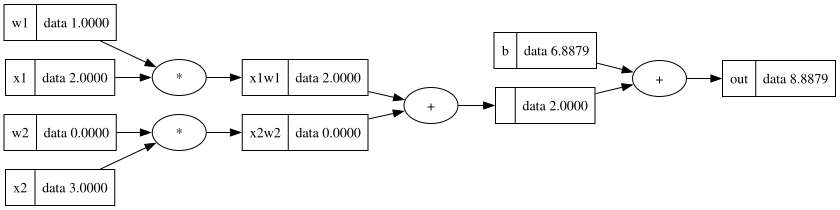

In [42]:
drawgraph(val)